<font size="6"> **ENG 07044 - Controle de Processos Industriais / DEQUI / UFRGS** </font>

<font size="5">
Introdução -- Controle da Temperatura de um Tanque com Tubulação Longa
</font>


         Prof. Dr. Jorge Otávio Trierweiler -- Jorge.Trierweiler@ufrgs.br


# Importando Pacotes e Inicializando
Praticamente esse é o conjunto de pacotes que devem ser carregados na maioria das nossas simulações. 
Boa parte dos nossos Notebooks deverão iniciar com esses comandos.

In [1]:
# Carregando os demais pacotes 
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as wg
import control.matlab as ml
from scipy import signal as sg
from scipy.integrate import solve_ivp

from plotly.subplots import make_subplots
import plotly.graph_objects as go

import plotly.io as pio
pio.templates.default = 'seaborn' #'plotly_dark' #seaborn' #'seaborn'
Opcoes = ['ggplot2', 'seaborn', 'simple_white', 'plotly',
         'plotly_white', 'plotly_dark', 'presentation', 'xgridoff',
         'ygridoff', 'gridon', 'none'];

# Configurando para os gráficos serem inseridos no Notebook
%matplotlib inline

# Planta de Tanque de Aquecimento com Tubulação Longa -- Modelo Matemático

O sistema que iremos analisar consiste em um tanque de aquecimento (similar a um chuveiro elétrico) que opera a volume constante seguido de uma tubulação longa. O objetivo de controle é a temperatura de saída dessa tubulação. 
Esquematicamente esse sistem é ilustrado na figura a seguir:
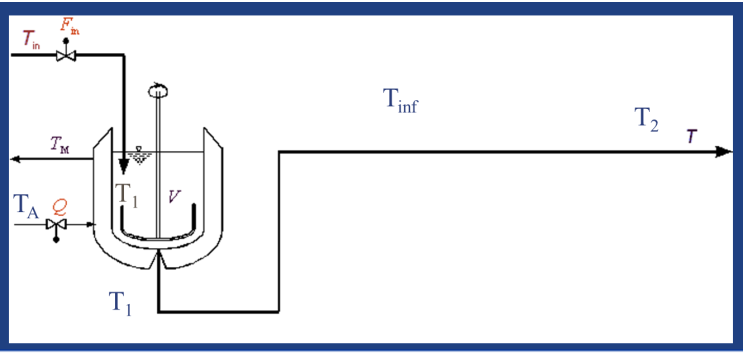

Esse planta pode ser descrita matemática por esse conjunto de equações diferencias:

**Balanço de Energia no TANQUE:**

$$ \frac{dT_1}{dt} = \frac{F_{in}}{V} (T_{in}-T_1) + \frac{Q_{max}}{\rho C_V V}z - \frac{UA}{\rho C_V V} (T_1 - T_{inf})$$

**Balanço de Energia na Tubulação:**

*a) Versão discretizada -- Sistema de **n** equações diferencias de 1ªordem em série*
 
$$ \frac{dT_i}{dt} = \frac{F_{in}n}{Vt} (T_{i-1}-T_i) - \frac{UA_t n}{\rho C_V V_t} (T_i - T_{inf})$$

N equações do tipo com $i = 1..n$
 
*b) Versão empistonada -- Tempo Morto*
     
$$ \theta = \frac{V_t}{F_{in}} $$

o problema é calcular a perda de calor na tubulação quando se utiliza apenas o atraso de transporte, aqui vai uma aproximação grosseira:
$$ 0 = \frac{F_{in}}{Vt} (T_1-T_f) - \frac{UA_t}{\rho C_V V_t} (T_f - T_{inf})$$

$$ T_f = \frac{T_1 + \frac{UA_t}{F_{in}} T_{inf}}{1 + \frac{UA_t}{F_{in}}}$$

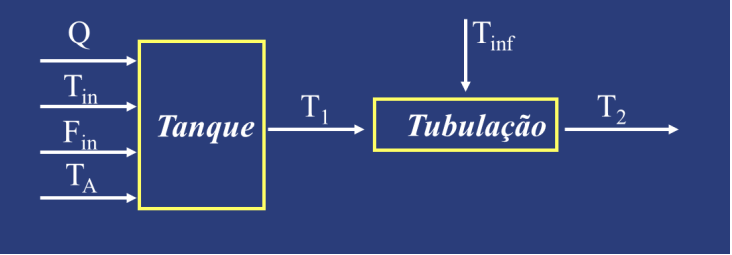

Como nosso sistema tem similaridades com um *chuveiro elétrico* fica aqui um link para contar um pouco da história do seu surgimente -- https://canaltech.com.br/produtos/quem-inventou-o-chuveiro-eletrico-217919/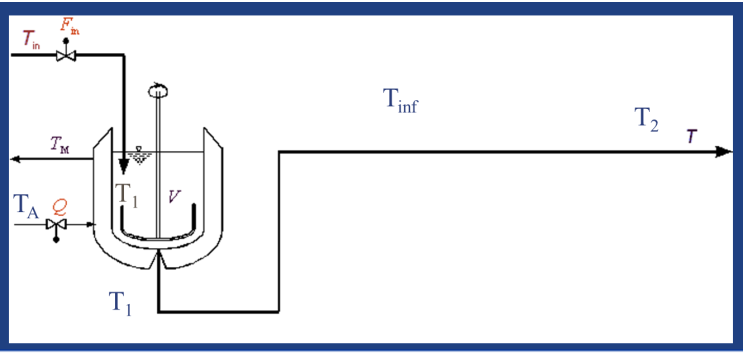

In [2]:
# modelo só do tanque
def TanqueAquecimento(t,T1,                           # tempo e variável de estado -- seguindo o padrão do integrado
                      z=70,Fin =10,Tin =25,Tinf= 25,  # manipuladas e distúrbios -- entradas
                      V=20,Qmax=800*20,UA =200):         # parâmetros físcos que descrevem o sistema
    return(((Fin/V)*(Tin-T1)+(Qmax/V)*z/100-(UA/V)*(T1-Tinf)))

## Comparando as abordagens puro atraso de transporte com primeira ordem em série

In [3]:
# modelo do tanque e da tubulação
UAt = 0.
def TanqueAquecimentoTubulacao(t,T,                                       # tempo e variável de estado -- seguindo o padrão do integrado
                               z=70,Fin =10,Tin =25,Tinf= 25,             # manipuladas e distúrbios -- entradas
                               V=20, Vt = 5, Qmax=800*20,UA =200, UAt = UAt):# parâmetros físcos que descrevem o sistema
    # O tamanho da discretização da tubulação é está associado ao número total de temperaturas
    # descontando um, pois a primeira temperatura corresponde a do tanque de aquecimento
    # N -- corresponde ao número total de temperaturas, ou seja, consiste na dimensão do vetor T
    
    N = np.size(T)
    return ([(Fin/V*(Tin-T[0])+(Qmax/V)*z/100-UA/V*(T[0]-Tinf))]
            + list((N-1)/Vt*(Fin*(T[0:N-1]-T[1:N])-UAt*(T[1:N]-Tinf))))     

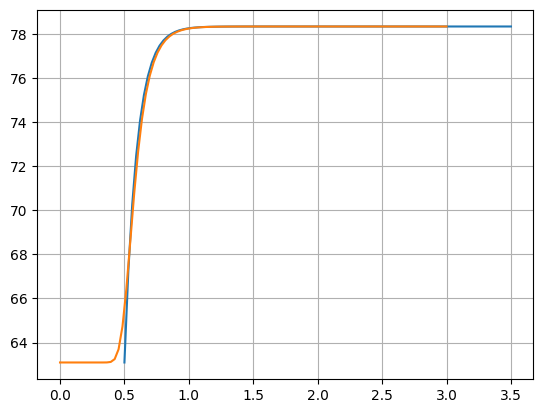

In [4]:
# comparando as abordagens
tq  = solve_ivp(TanqueAquecimento,[0, 3],[63.098], t_eval = np.linspace(0,3,100), rtol=1e-6 )
UAt = 0.0
tqt = solve_ivp(TanqueAquecimentoTubulacao,[0, 3],63.098*np.ones(100), t_eval = np.linspace(0,3,100), rtol=1e-6 )
plt.plot(tq.t+0.5,tq.y[0,:])
plt.plot(tqt.t,tqt.y[-1,:])
plt.grid()

## Determinação da condição estacionário 

In [5]:
UAt = 0.01
def TanqueAquecimentoTubulacao(t,T,                                       # tempo e variável de estado -- seguindo o padrão do integrado
                               z=50,Fin =10,Tin =25,Tinf= 25,             # manipuladas e distúrbios -- entradas
                               V=20, Vt = 5, Qmax=800*20,UA =200, UAt = UAt):# parâmetros físcos que descrevem o sistema
    # O tamanho da discretização da tubulação é está associado ao número total de temperaturas
    # descontando um, pois a primeira temperatura corresponde a do tanque de aquecimento
    # N -- corresponde ao número total de temperaturas, ou seja, consiste na dimensão do vetor T
    
    N = np.size(T)
    return ([(Fin/V*(Tin-T[0])+(Qmax/V)*z/100-UA/V*(T[0]-Tinf))]
            + list((N-1)/Vt*(Fin*(T[0:N-1]-T[1:N])-UAt*(T[1:N]-Tinf))))     

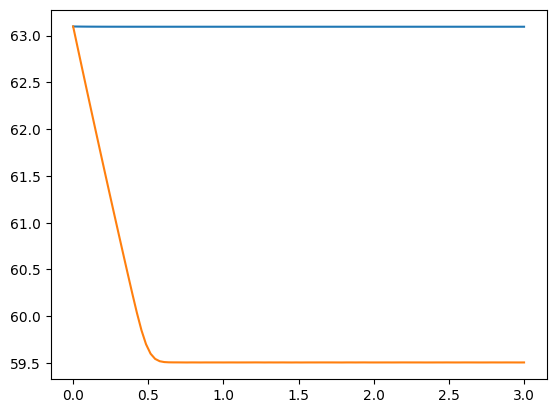

In [6]:
# determinação do valor estacionário
sol = solve_ivp(TanqueAquecimentoTubulacao,[0, 3],63.098*np.ones(100), 
                t_eval = np.linspace(0,3,100),args=(50,10), rtol=1e-6 )
T0 = sol.y[:,-1]  # agora temos em T0 as temperaturas iniciais estacionárias para 50% da potência
plt.plot(sol.t,sol.y[0,:])
plt.plot(sol.t,sol.y[-1,:]);

# Simulação em malha aberta -- para várias perturbações


In [7]:
def Simulacao_MA (SYS, y0, TU, dt=0.01, Matplot = False, Plotly = False):
    
    # Armazenamento dos dados resultantes da simulação
    Tfinal = TU[-1,0] 
    
    #(Ad,Bd,Cd,Dd,dt)=sg.cont2discrete(SS_Planta(P),dt)
    # calculo do deslocamento do tempo morto (kd)
    #kd = int(round(P['TempoMorto']/dt,0))

    # Armazenamento dos dados resultantes da simulação

    TT = np.arange(start=0,stop=Tfinal+dt,step = dt, dtype='float')
    NT = np.size(TT)
    NY = np.size(y0)
    YY = np.zeros((NT,NY))
    nu = np.size(TU,1)
    UU = np.zeros((NT,nu-1))

    #x = np.zeros((3,1)) # condição inicial do modelo linear

    ii = 0    
    YY[0,:]=y0
    
    for k in np.arange(NT-1):
        
        if TT[k] >= TU[ii+1,0]:
            ii=ii+1
    
        # Definição das variáveis de entrada
        UU[k,:] = TU[ii,1:nu]
    
           
        # Armazenamento dos valores calculados
        
        sol = solve_ivp(SYS,[TT[k], TT[k+1]],YY[k,:], args = tuple(UU[k]), rtol =1e-6) #,method="RK45",max_step = dt, atol=1, rtol=1)
                        
        YY[k+1,:]=sol.y[:,-1]    
                        
                        
    #erro = yy_f-YY
    UU[k+1,:] = TU[ii,1:nu]
    
    if Matplot:
        plt.figure(figsize=(12,6))
        plt.subplot(2,1,1)    
        
        plt.plot(TT,YY[:,0])            # respota obtida em simulação discreta
        plt.plot(TT,YY[:,-1]) 
        plt.legend(['T1','Tf'])
        plt.title('Saídas ( $T_1$ e $T_f$ )')
        plt.grid()
        plt.subplot(2,1,2)
        plt.title (r'Entradas (MV e Distúrbios)')
        plt.plot(TT,UU)
        plt.legend(['z','Fin','Tin','Tinf'])
        plt.xlabel('Tempo [min]')
        plt.grid()
        
    if Plotly:
        fig = make_subplots(2,1)
        fig.add_trace(go.Scatter(name='T1', x=TT, y=YY[:,0]),1,1)
        fig.add_trace(go.Scatter(name='Tf', x=TT, y=YY[:,-1]),1,1)
        
        fig.add_trace(go.Scatter(name='z', x=TT, y=UU[:,0],line= {"shape": 'hv'}),2, 1 )        
        fig.add_trace(go.Scatter(name='Fin', x=TT, y=UU[:,1],line= {"shape": 'hv'}),2, 1 ) 
        fig.add_trace(go.Scatter(name='Tin', x=TT, y=UU[:,2],line= {"shape": 'hv'}),2, 1 ) 
        fig.add_trace(go.Scatter(name='Tinf', x=TT, y=UU[:,3],line= {"shape": 'hv'}),2, 1 ) 
        fig.update_xaxes(matches='x')
  
        
        fig.update_layout(
            height=500, 
            width = 800,
            title={
            'text': 'Saídas ( T1 e Tf )',
            'y':0.85,
            'x':0.5,
            'xanchor': 'center',
            'yanchor': 'top'},
            xaxis_title = r'Entradas (MV e Distúrbios)',
            yaxis_title='Temperaturas',
            legend_title="Variáveis",
        )
        fig.show() 
        
    return (TT,YY,UU)


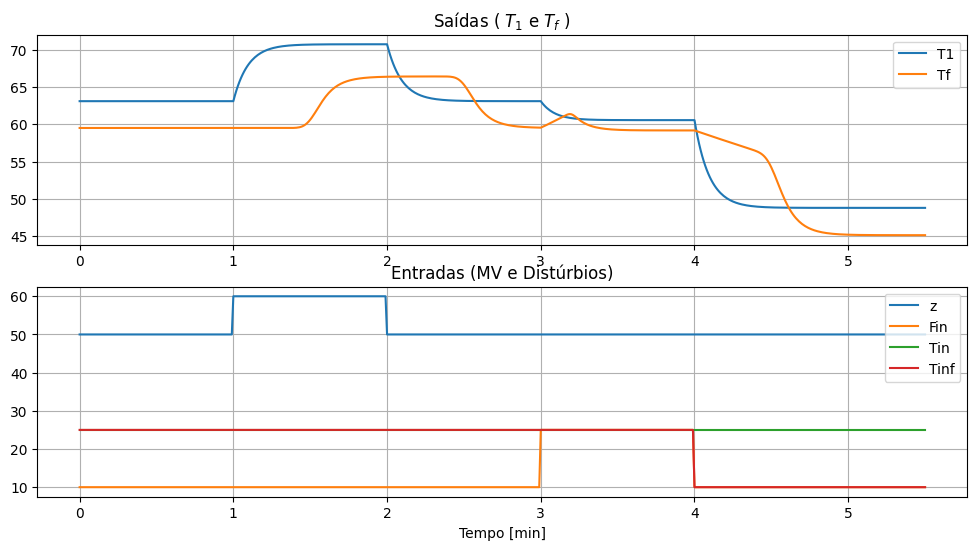

In [8]:
TU =np.array(
[    # Time,   z ,  Fin , Tin, Tinf
      [  0 ,  50 ,  10  ,  25, 25  ],
      [  1 ,  60 ,  10  ,  25, 25  ],
      [  2 ,  50 ,  10  ,  25, 25  ],
      [  3 ,  50 ,  25  ,  25, 25  ],
      [  4 ,  50 ,  10  ,  25, 10  ],
      [  5.5 ,  50 ,  10  ,  25, 10  ],
])      

Simulacao_MA(TanqueAquecimentoTubulacao, T0, TU, 0.01,Plotly=True, Matplot =True);

# Malha Feedback (retroalimentada ou realimentada)
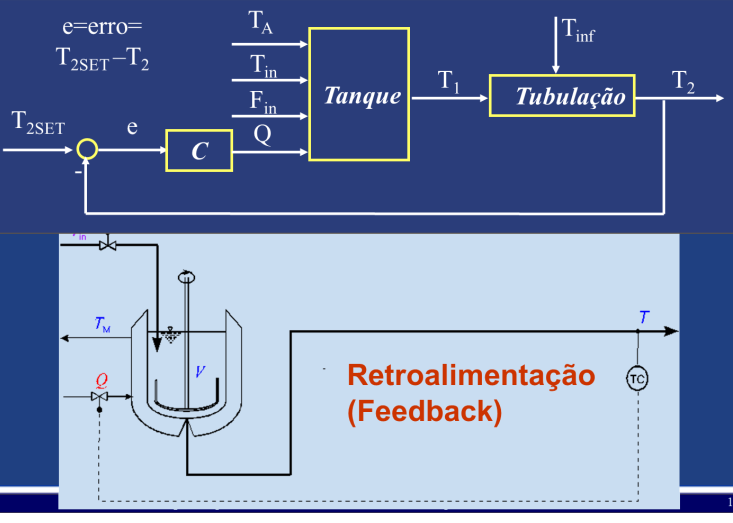

In [9]:
def PID_p2(SP, PV,k,I_int,D_int, dt, Method = 'Backward', Kp=10.0, Ti=50.0, Td=1.0, b=1.,c=0.0, 
           N=10., U_bias = 0., Umin = -100.,Umax = 100.):
    # PID -- posicional implementation   
    # Para sistemas não lineares com ação integral e b!=1 inicializar I_int =  Kp*Yset_bias*(1-b)    
    # The approximation of the derivative term are stable only when abs(ad)<1. 
    # The forward difference approximation requires that Td>N*dt/2, i.e., the 
    # approximation becomes unstable for small values of Td. The other approximation
    # are stable for all values of Td. 
    
    # Autor: Jorge Otávio Trierweiler -- jorge.trierweiler@ufrgs.br
    
    if Method == 'Backward':
        b1 = Kp*dt/Ti if Ti != 0 else 0.0
        b2 = 0.0
        ad = Td/(Td+N*dt)
        bd = Kp*Td*N/(Td+N*dt)
    elif Method == 'Forward':
        b1 = 0.0
        b2 = Kp*dt/Ti  if Ti!=0 else 0.0
        ad = 1-N*dt/Td if Td!=0 else 0.0
        bd = Kp*N   
    elif Method == 'Tustin':
        b1 = Kp*dt/2/Ti if Ti!=0 else 0.0
        b2 = b1
        ad = (2*Td-N*dt)/(2*Td+N*dt)
        bd = 2*Kp*Td*N/(2*Td+N*dt)   
    elif Method == 'Ramp':
        b1 = Kp*dt/2/Ti if Ti!=0 else 0.0
        b2 = b1
        ad = np.exp(-N*dt/Td) if Td !=0 else 0.0
        bd = Kp*Td*(1-ad)/dt
        
    # Derivative Action 
    D  = ad*D_int+bd*((c*SP[k]-PV[k])-(c*SP[k-1]-PV[k-1]))
    
    # Integral action
    
    II = b1*(SP[k]-PV[k])+b2*(SP[k-1]-PV[k-1])
    #II = Kp*dt/Ti*(SP[k]-PV[k]) if Ti!=0 else 0.0
    I = I_int + II                         
   
     
    # calculate the PID output
    P = Kp * (b*SP[k]-PV[k])
       
    Uop = U_bias + P + I + D

    # implement anti-reset windup

    if Uop < Umin:
        II = 0.0      # no caso de saturação -- diminuindo o valor integrado a mais
        Uop = Umin
    if Uop > Umax:
        II = 0.0
        Uop = Umax
    
        
    # return the controller output and PID terms
    return np.array([ Uop, I_int+II, D])

In [10]:
TU =np.array(
[    # Time,   SP ,  Fin , Tin, Tinf
      [  0 ,  63 ,  10  ,  25, 25  ],
      [  1 ,  70 ,  10  ,  25, 25  ],
      [  2 ,  60 ,  10  ,  25, 25  ],
      [  3 ,  60 ,  20  ,  25, 25  ],
      [  4 ,  60 ,  20  ,  10, 10  ],
      [  5 ,  60 ,  20  ,  10, 10  ],
])      


def Simulacao_MF (SYS, y0, TU, CV =0 ,                      # escolha do modelo, condição inicial, padrão de perturbação e CV (variável controlada)
                  Kp=2, Ti=0.4, Td=0, b=1, U_bias=50,      # parâmetros de ajuste do controlador 
                  Ruido = 0.005,  dt=0.01, Matplot = False, Plotly = False ):# dados complementares
    
    # Armazenamento dos dados resultantes da simulação
    Tfinal = TU[-1,0] 
    
    #(Ad,Bd,Cd,Dd,dt)=sg.cont2discrete(SS_Planta(P),dt)
    # calculo do deslocamento do tempo morto (kd)
    #kd = int(round(P['TempoMorto']/dt,0))

    # Armazenamento dos dados resultantes da simulação

   
    Yset_bias = y0[CV]
    
    TT = np.arange(start=0,stop=Tfinal+dt,step = dt, dtype='float')
    NT = np.size(TT)
    NY = np.size(y0)
    YY = np.zeros((NT,NY))
    nu = np.size(TU,1)
    UU = np.zeros((NT,nu-1))
    SP = np.zeros_like(TT)
    PV = np.ones_like(TT)*Yset_bias
    Noise = np.random.normal(0, Ruido, len(TT))
    #x = np.zeros((3,1)) # condição inicial do modelo linear
    

    ii = 0    
    
    D_int = 0.0  
    I_int = Kp*Yset_bias*(1-b)
    
    YY[0,:]=y0
      
    
    for k in np.arange(NT-1):
        
        if TT[k] >= TU[ii+1,0]:
            ii=ii+1
    
        # Definição do setpoint e do distúrbio na carga
        UU[k,:] = TU[ii,1:nu]
    
        SP[k] = TU[ii,1]
         
        PV[k]=YY[k,CV]+Noise[k]    
        # Armazenamento dos valores calculados
        uu = PID_p2(SP,PV,k,I_int, D_int, dt, Method ='Backward',
                Kp=Kp,Ti=Ti,Td=Td,N=10,b=b, 
                Umin=0, Umax=100, U_bias = U_bias)
        Uop   = uu[0]
        I_int = uu[1]
        D_int = uu[2]
        
        # Definição do setpoint e do distúrbio na carga
        UU[k,0] = Uop
    
        sol = solve_ivp(SYS,[TT[k], TT[k+1]],YY[k,:], args = tuple(UU[k]), rtol =1e-6) #,method="RK45",max_step = dt, atol=1, rtol=1)
                        
        YY[k+1,:]=sol.y[:,-1]    
                        
                        
    #erro = yy_f-YY
    
    UU[k+1,:] = TU[ii,1:nu]
    UU[k+1,0] = Uop
    SP[k+1] = TU[ii,1]
    
    if Matplot:
        plt.figure(figsize=(12,6))
        plt.subplot(2,1,1)    
        
        plt.plot(TT,YY[:,0])            # respota obtida em simulação discreta
        plt.plot(TT,YY[:,-1]) 
        plt.plot(TT,SP)
        plt.title('Saídas -- ($T_1$. $T_f$ e $SP$)')
        plt.legend(['T1','Tf','SP'])
        #plt.plot(r['time'],'y']) # resposta anterior -- rodando tudo de uma só vez
        plt.grid()
        plt.subplot(2,1,2)
        plt.plot(TT,UU)
        plt.title('Entradas (MV e Distúrbios)')
        plt.legend(['z','Fin','Tin','Tinf'])
        plt.xlabel('Tempo [min]')
        plt.grid()
        
    if Plotly:
        fig = make_subplots(2,1)
        fig.add_trace(go.Scatter(name='T1', x=TT, y=YY[:,0]),1,1)
        fig.add_trace(go.Scatter(name='Tf', x=TT, y=YY[:,-1]),1,1)
        fig.add_trace(go.Scatter(name='SP', x=TT, y=SP,line= {"shape": 'hv'}),1,1)
        
        fig.add_trace(go.Scatter(name='z', x=TT, y=UU[:,0],line= {"shape": 'hv'}),2, 1 )        
        fig.add_trace(go.Scatter(name='Fin', x=TT, y=UU[:,1],line= {"shape": 'hv'}),2, 1 ) 
        fig.add_trace(go.Scatter(name='Tin', x=TT, y=UU[:,2],line= {"shape": 'hv'}),2, 1 ) 
        fig.add_trace(go.Scatter(name='Tinf', x=TT, y=UU[:,3],line= {"shape": 'hv'}),2, 1 ) 
        fig.update_xaxes(matches='x')
  
        
        fig.update_layout(
            height=500, 
            width = 800,
            title={
            'text': 'Saídas ( T1 e Tf )',
            'y':0.85,
            'x':0.5,
            'xanchor': 'center',
            'yanchor': 'top'},
            xaxis_title = r'Entradas (MV e Distúrbios)',
            yaxis_title='Temperaturas',
            legend_title="Variáveis",
        )
        fig.show() 

        
    
        
    return (TT,YY,UU)


In [11]:
TU =np.array(
[    # Time,   SP ,  Fin , Tin, Tinf
      [  0 ,  63 ,  10  ,  25, 25  ],
      [  3,  70 ,  10  ,  25, 25  ],
      [  6 ,  60 ,  10  ,  25, 25  ],
      [  9 ,  60 ,  20  ,  25, 25  ],
      [  12 ,  60 ,  10  ,  10, 25  ],
      [  15 ,  60 ,  10  ,  10, 10  ],
      [  18,   60,   10  ,  40, 20  ],
      [  22,   60,   10  ,  40, 20  ],
])        

Simulacao_MF (TanqueAquecimentoTubulacao, T0, TU, CV =-1, Kp=1,Ti=0.3,Td=0.1,b=1,
              Ruido = 0.05, U_bias=50, dt=0.01, Plotly = True );

In [12]:
def wg_MF (Kp=0.91,Ti=0.57,Td=0.0, b=1., CV_txt = 'T1'):
    CV = -1
    if CV_txt =='T1':
        CV = 0
    Simulacao_MF (TanqueAquecimentoTubulacao, T0, TU, CV =CV,Kp=Kp,Ti=Ti,Td=Td,b=b,
              Ruido = 0.005, U_bias=50, dt=0.051, Plotly = True );

In [13]:
wg.interact(wg_MF,Kp=(0.01,5), Ti=(0.01, 2.,0.005), Td =(0.0, 3), b=(0.01,4), CV_txt = ['T1','Tf']);

interactive(children=(FloatSlider(value=0.91, description='Kp', max=5.0, min=0.01), FloatSlider(value=0.57, de…

# Malha Cascata
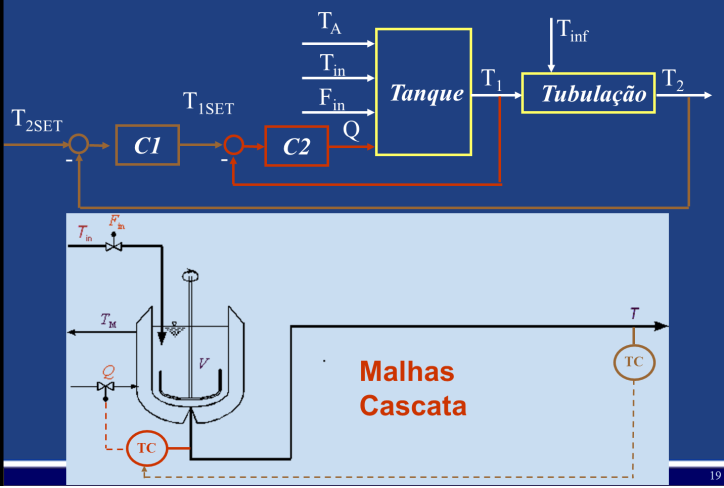

In [14]:
TU =np.array(
[    # Time,  SP , Fin , Tin, Tinf
      [  0 ,  63 ,   10  ,  25, 25  ],
      [  1 ,  70 ,  10  ,  25, 25  ],
      [  2 ,  60 ,  10  ,  25, 25  ],
      [  3 ,  60 ,  20  ,  25, 25  ],
      [  4 ,  60 ,  20  ,  10, 10  ],
      [  5 ,  60 ,  20  ,  10, 10  ],
])      


def Simulacao_MF_Cascata (SYS, y0, TU, Kp=[1,2.41],Ti=[0.6,0.1],Td=[0,0],b=[1,1], 
                          Ruido = 0.005, U_bias=50, dt=0.01,  Matplot = False, Plotly = False ):
    
    # Armazenamento dos dados resultantes da simulação
    Tfinal = TU[-1,0] 
    
    #(Ad,Bd,Cd,Dd,dt)=sg.cont2discrete(SS_Planta(P),dt)
    # calculo do deslocamento do tempo morto (kd)
    #kd = int(round(P['TempoMorto']/dt,0))

    # Armazenamento dos dados resultantes da simulação

   
    Yset_bias = y0[[-1,0]]
    
    TT = np.arange(start=0,stop=Tfinal+dt,step = dt, dtype='float')
    NT = np.size(TT)
    NY = np.size(y0)
    YY = np.zeros((NT,NY))
    nu = np.size(TU,1)
    UU = np.zeros((NT,nu-1))
    SP0 = np.zeros_like(TT)
    SP1 = np.zeros_like(TT)
    PV0 = np.ones_like(TT)*Yset_bias[0]
    PV1 = np.ones_like(TT)*Yset_bias[1]
    Noise = np.random.normal(0, Ruido, len(TT))
    #x = np.zeros((3,1)) # condição inicial do modelo linear
    

    ii = 0    
    
    D_int0 = 0.0  
    I_int0 = Kp[0]*Yset_bias[0]*(1-b[0])
    
    D_int1 = 0.0  
    I_int1 = Kp[1]*Yset_bias[1]*(1-b[1])
    
    YY[0,:]=y0
      
    
    for k in np.arange(NT-1):
        
        if TT[k] >= TU[ii+1,0]:
            ii=ii+1
    
        # Definição do setpoint e do distúrbio na carga
        UU[k,:] = TU[ii,1:nu]
    
        SP0[k] = TU[ii,1]
         
        PV0[k]=YY[k,-1]+Noise[k]  
        PV1[k]=YY[k,0] +Noise[k]
        # Armazenamento dos valores calculados
        uu = PID_p2(SP0,PV0,k,I_int0, D_int0, dt, Method ='Backward',
                Kp=Kp[0],Ti=Ti[0],Td=Td[0],N=10,b=b[0], 
                Umin=0, Umax=1000, U_bias = Yset_bias[1])
        SP1[k]   = uu[0]
        I_int0 = uu[1]
        D_int0 = uu[2]
        
        uu = PID_p2(SP1,PV1,k,I_int1, D_int1, dt, Method ='Backward',
                Kp=Kp[1],Ti=Ti[1],Td=Td[1],N=10,b=b[1], 
                Umin=0, Umax=100, U_bias = U_bias)
        Uop    = uu[0]
        I_int1 = uu[1]
        D_int1 = uu[2]
        
        # Definição do setpoint e do distúrbio na carga
        UU[k,0] = Uop
    
        sol = solve_ivp(SYS,[TT[k], TT[k+1]],YY[k,:], args = tuple(UU[k]), rtol =1e-6) #,method="RK45",max_step = dt, atol=1, rtol=1)
                        
        YY[k+1,:]=sol.y[:,-1]    
                        
                        
    #erro = yy_f-YY
    
    UU[k+1,:] = TU[ii,1:nu]
    UU[k+1,0] = Uop
    SP0[k+1] = TU[ii,1]
    SP1[k+1] = SP1[k]
    if Matplot:
        plt.figure(figsize=(12,6))
        plt.subplot(2,1,1)    
        
        plt.plot(TT,YY[:,0])            # respota obtida em simulação discreta
        plt.plot(TT,YY[:,-1]) 
        plt.plot(TT,SP0)
        plt.plot(TT,SP1)
        plt.title('Saídas -- ($T_1$. $T_f$, $SP_1$ e $SP_2$)')
        plt.legend(['T1','Tf','$SP_f$','$SP_1$'])
        #plt.plot(r['time'],'y']) # resposta anterior -- rodando tudo de uma só vez
        plt.grid()
        plt.subplot(2,1,2)
        plt.plot(TT,UU)
        plt.title('Entradas  (MV e distúrbios)')
        plt.xlabel('Tempo [min]')
        plt.legend(['z','Fin','Tin','Tinf'])
        plt.grid()
        
    if Plotly:
        fig = make_subplots(2,1)
        fig.add_trace(go.Scatter(name='T1', x=TT, y=YY[:,0]),1,1)
        fig.add_trace(go.Scatter(name='Tf', x=TT, y=YY[:,-1]),1,1)
        fig.add_trace(go.Scatter(name='SPf', x=TT, y=SP0,line= {"shape": 'hv'}),1,1)
        fig.add_trace(go.Scatter(name='SP1', x=TT, y=SP1,line= {"shape": 'hv'}),1,1)
        
        fig.add_trace(go.Scatter(name='z', x=TT, y=UU[:,0],line= {"shape": 'hv'}),2, 1 )        
        fig.add_trace(go.Scatter(name='Fin', x=TT, y=UU[:,1],line= {"shape": 'hv'}),2, 1 ) 
        fig.add_trace(go.Scatter(name='Tin', x=TT, y=UU[:,2],line= {"shape": 'hv'}),2, 1 ) 
        fig.add_trace(go.Scatter(name='Tinf', x=TT, y=UU[:,3],line= {"shape": 'hv'}),2, 1 ) 
        fig.update_xaxes(matches='x')
  
        
        fig.update_layout(
            height=500, 
            width = 800,
            title={
            'text': 'Saídas ( T1 e Tf )',
            'y':0.85,
            'x':0.5,
            'xanchor': 'center',
            'yanchor': 'top'},
            xaxis_title = r'Entradas (MV e Distúrbios)',
            yaxis_title='Temperaturas',
            legend_title="Variáveis",
        )
        fig.show() 

        
    return (TT,YY,UU)


In [15]:
TU =np.array(
[    # Time,   SP ,  Fin , Tin, Tinf
      [  0 ,  63 ,  10  ,  25, 25  ],
      [  3,  70 ,  10  ,  25, 25  ],
      [  6 ,  60 ,  10  ,  25, 25  ],
      [  9 ,  60 ,  20  ,  25, 25  ],
      [  12 ,  60 ,  10  ,  10, 25  ],
      [  15 ,  60 ,  10  ,  10, 10  ],
      [  18,   60,   10  ,  40, 20  ],
      [  22,   60,   10  ,  40, 20  ],
])        
Simulacao_MF_Cascata (TanqueAquecimentoTubulacao, T0, TU, Kp=[0.795,5],Ti=[0.5,5],Td=[0.01,0],b=[2,1], Ruido = 0.05, U_bias=50, dt=0.01, Plotly = True );

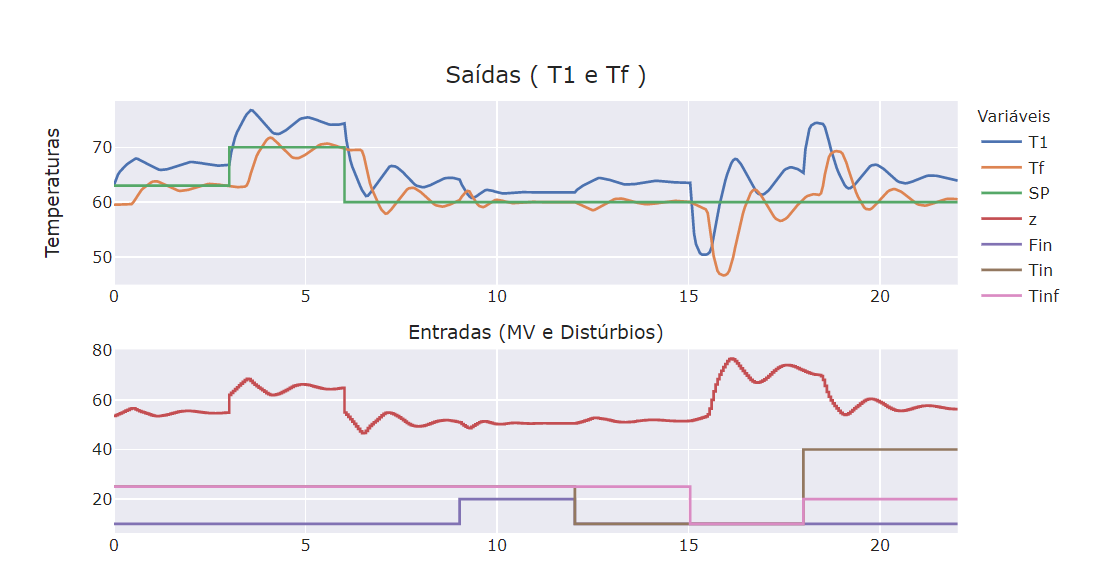

In [16]:
def wg_MF_cascata(Kp_ext = 1., Ti_ext = 0.21, b_ext = 1 , Kp_in =7.2 , Ti_in = 2.30, b_in = 0.5):
    Simulacao_MF_Cascata (TanqueAquecimentoTubulacao, T0, TU, Kp=[Kp_ext,Kp_in],Ti=[Ti_ext,Ti_in],Td=[0.0,0],b=[b_ext,b_in], Ruido = 0.005, U_bias=50, dt=0.01, Plotly = True )

In [17]:
wg.interact(wg_MF_cascata, Kp_ext = (0.01, 2), Ti_ext = (0.01, 2,0.01), b_ext =(0.01,3) , Kp_in =(0.01, 10) , Ti_in =(0.01,10) , b_in = (0.01,3));

interactive(children=(FloatSlider(value=1.0, description='Kp_ext', max=2.0, min=0.01), FloatSlider(value=0.21,…

# Malha Antecipativa -- Feedforward + FeedBack
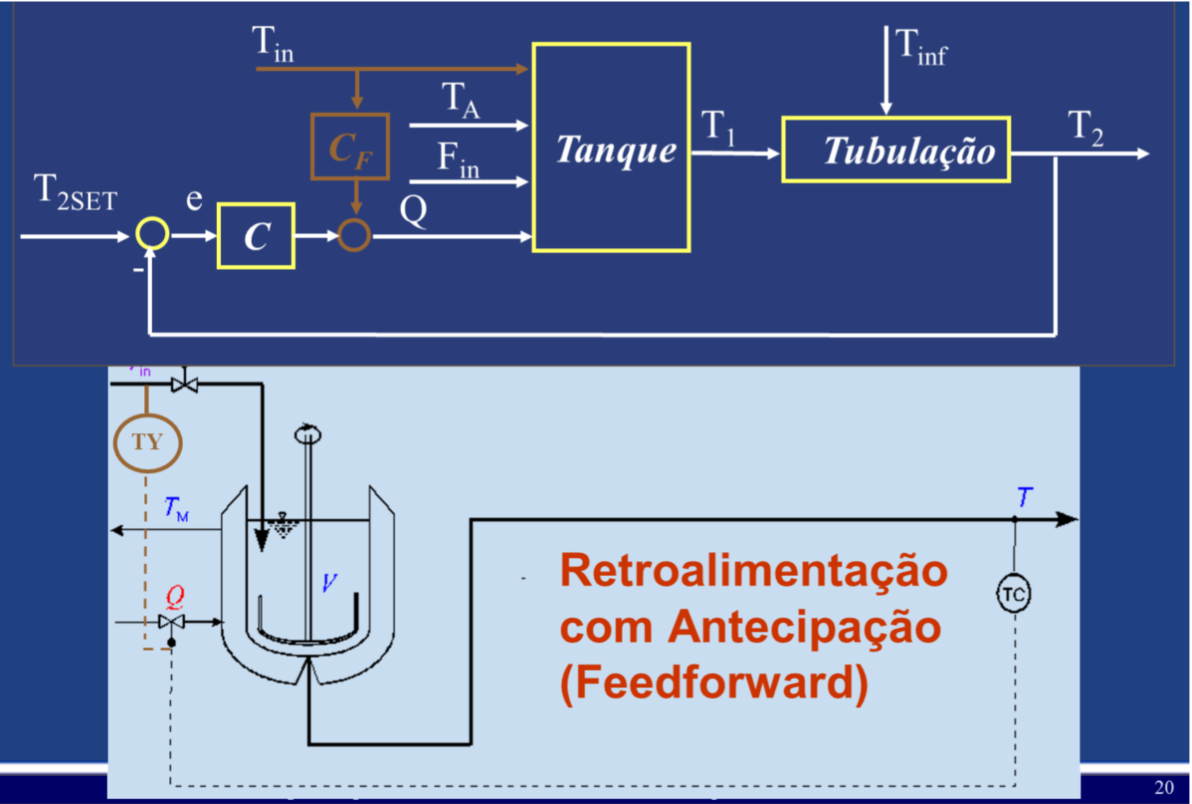

Aqui vamos implementar um controlador **Antecipativo** tendo a temperatura de alimentação como distúrbio medido. Para projetar as ações de controle faremos uso do modelo 
$$ \frac{dT_1}{dt} = \frac{F_{in}}{V} (T_{in}-T_1) + \frac{Q_{max}}{\rho C_V V}z - \frac{UA}{\rho C_V V} (T_1 - T_{inf})$$

Agora vamos calcular o valor da potência necessária para compensar uma tempetur de entrada, a qual é dada por:
$$ 0 = \frac{F_{in}}{V} (T_{in}-T_1) + \frac{Q_{max}}{\rho C_V V}z $$
que isolando para z  chegamos a expressão base da implementação:
$$ z = \frac{F_{in} \rho C_V}{Q_{max}} (T_1-T_{in})$$
A implementação será através da atualização do valor do U_bias do controlador.

In [18]:
TU =np.array(
[    # Time,   SP ,  Fin , Tin, Tinf
      [  0 ,  63 ,  10  ,  25, 25  ],
      [  1 ,  70 ,  10  ,  25, 25  ],
      [  2 ,  60 ,  10  ,  25, 25  ],
      [  3 ,  60 ,  20  ,  25, 25  ],
      [  4 ,  60 ,  20  ,  10, 10  ],
      [  5 ,  60 ,  20  ,  10, 10  ],
])      


def Simulacao_MF_FF (SYS, y0, TU, CV =-1 ,                # escolha do modelo, condição inicial, padrão de perturbação e CV (variável controlada)
                  Kp=2, Ti=0.4, Td=0, b=1, U_bias=50,      # parâmetros de ajuste do controlador 
                  Ruido = 0.005,  dt=0.01, Matplot = False, Plotly = False ):# dados complementares
    
    # Armazenamento dos dados resultantes da simulação
    Tfinal = TU[-1,0] 
    
    #(Ad,Bd,Cd,Dd,dt)=sg.cont2discrete(SS_Planta(P),dt)
    # calculo do deslocamento do tempo morto (kd)
    #kd = int(round(P['TempoMorto']/dt,0))

    # Armazenamento dos dados resultantes da simulação

   
    Yset_bias = y0[CV]
    
    TT = np.arange(start=0,stop=Tfinal+dt,step = dt, dtype='float')
    NT = np.size(TT)
    NY = np.size(y0)
    YY = np.zeros((NT,NY))
    nu = np.size(TU,1)
    UU = np.zeros((NT,nu-1))
    SP = np.zeros_like(TT)
    PV = np.ones_like(TT)*Yset_bias
    Noise = np.random.normal(0, Ruido, len(TT))
    #x = np.zeros((3,1)) # condição inicial do modelo linear
    

    ii = 0    
    
    D_int = 0.0  
    I_int = Kp*Yset_bias*(1-b)
    
    YY[0,:]=y0
      
    
    for k in np.arange(NT-1):
        
        if TT[k] >= TU[ii+1,0]:
            ii=ii+1
    
        # Definição do setpoint e do distúrbio na carga
        UU[k,:] = TU[ii,1:nu]
    
        SP[k] = TU[ii,1]
         
        PV[k]=YY[k,CV]+Noise[k]    
        
        #ação antecipativa
        z_FF = 5/80*(25-TU[ii,3])        
        
        # Armazenamento dos valores calculados
        uu = PID_p2(SP,PV,k,I_int, D_int, dt, Method ='Backward',
                Kp=Kp,Ti=Ti,Td=Td,N=10,b=b, 
                Umin=0, Umax=100, U_bias = U_bias + z_FF)
        Uop   = uu[0]
        I_int = uu[1]
        D_int = uu[2]
        
        # Definição do setpoint e do distúrbio na carga
        UU[k,0] = Uop 
    
        sol = solve_ivp(SYS,[TT[k], TT[k+1]],YY[k,:], args = tuple(UU[k]), rtol =1e-6) #,method="RK45",max_step = dt, atol=1, rtol=1)
                        
        YY[k+1,:]=sol.y[:,-1]    
                        
                        
    #erro = yy_f-YY
    
    UU[k+1,:] = TU[ii,1:nu]
    UU[k+1,0] = Uop
    SP[k+1] = TU[ii,1]
    
    if Matplot:
        plt.figure(figsize=(12,6))
        plt.subplot(2,1,1)    
        
        plt.plot(TT,YY[:,0])            # respota obtida em simulação discreta
        plt.plot(TT,YY[:,-1]) 
        plt.plot(TT,SP)
        plt.title('Saídas -- ($T_1$. $T_f$ e $SP$)')
        plt.legend(['T1','Tf','SP'])
        #plt.plot(r['time'],'y']) # resposta anterior -- rodando tudo de uma só vez
        plt.grid()
        plt.subplot(2,1,2)
        plt.plot(TT,UU)
        plt.title('Entradas (MV e Distúrbios)')
        plt.legend(['z','Fin','Tin','Tinf'])
        plt.xlabel('Tempo [min]')
        plt.grid()
        
    if Plotly:
        fig = make_subplots(2,1)
        fig.add_trace(go.Scatter(name='T1', x=TT, y=YY[:,0]),1,1)
        fig.add_trace(go.Scatter(name='Tf', x=TT, y=YY[:,-1]),1,1)
        fig.add_trace(go.Scatter(name='SP', x=TT, y=SP,line= {"shape": 'hv'}),1,1)
        
        fig.add_trace(go.Scatter(name='z', x=TT, y=UU[:,0],line= {"shape": 'hv'}),2, 1 )        
        fig.add_trace(go.Scatter(name='Fin', x=TT, y=UU[:,1],line= {"shape": 'hv'}),2, 1 ) 
        fig.add_trace(go.Scatter(name='Tin', x=TT, y=UU[:,2],line= {"shape": 'hv'}),2, 1 ) 
        fig.add_trace(go.Scatter(name='Tinf', x=TT, y=UU[:,3],line= {"shape": 'hv'}),2, 1 ) 
        fig.update_xaxes(matches='x')
  
        
        fig.update_layout(
            height=500, 
            width = 800,
            title={
            'text': 'Saídas ( T1 e Tf )',
            'y':0.85,
            'x':0.5,
            'xanchor': 'center',
            'yanchor': 'top'},
            xaxis_title = r'Entradas (MV e Distúrbios)',
            yaxis_title='Temperaturas',
            legend_title="Variáveis",
        )
        fig.show() 

        
    
        
    return (TT,YY,UU)



In [19]:
TU =np.array(
[    # Time,   SP ,  Fin , Tin, Tinf
      [  0 ,  63 ,  10  ,  25, 25  ],
      [  3,  70 ,  10  ,  25, 25  ],
      [  6 ,  60 ,  10  ,  25, 25  ],
      [  9 ,  60 ,  20  ,  25, 25  ],
      [  12 ,  60 ,  10  ,  10, 25  ],
      [  15 ,  60 ,  10  ,  30, 25  ],
      [  18,   60,   10  ,  10, 25  ],
      [  22,   60,   10  ,  10, 25  ],
])      


Simulacao_MF_FF (TanqueAquecimentoTubulacao, T0, TU, CV =-1, Kp=1,Ti=0.3,Td=0.1,b=1,
              Ruido = 0.05, U_bias=50, dt=0.01, Plotly = True );


Controlador sem Feedforward
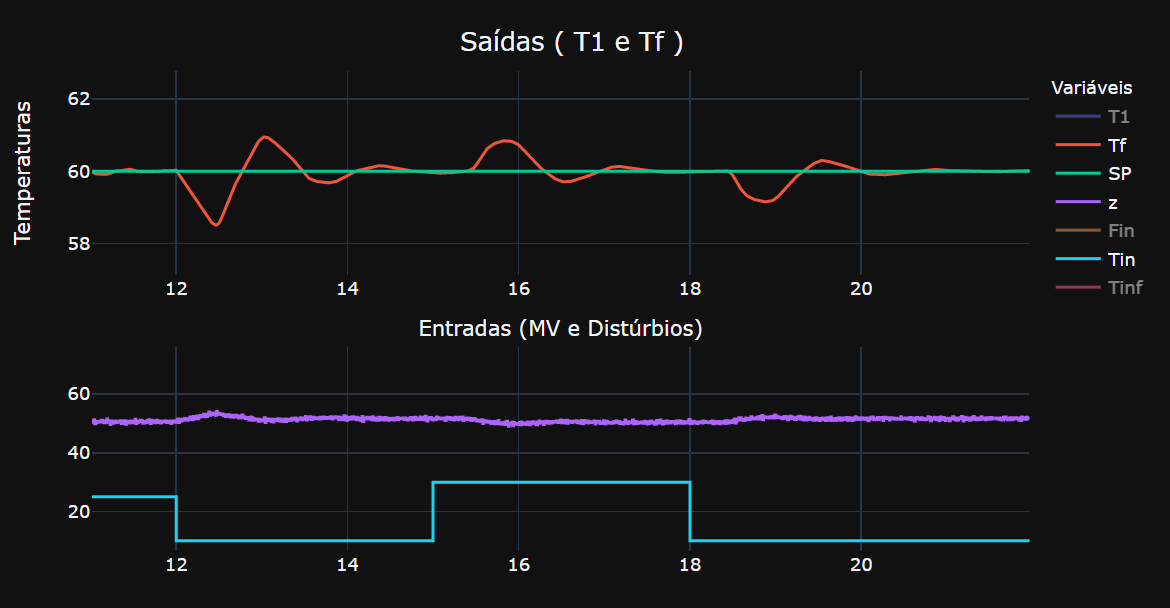